<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 1: Implementación de un modelo por Random Forest</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> En esta actividad construiras un clasificadore basados en **Random Forest** para predecir la **aceptabilidad/seguridad de un automóvil**. 
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Entrenar dos modelos (con pocos y con muchos árboles) para observar cómo mejora la exactitud, demostrar el proceso de **selección de características** basado en la importancia de variables, y reconstruir el modelo con las variables más relevantes. </li>

</ul>
</div>

**Random Forest** (bosque aleatorio) es un algoritmo de **aprendizaje supervisado** basado en **ensamble** (*ensemble learning*). Tiene dos variantes: una para **clasificación** y otra para **regresión**. Es uno de los algoritmos más flexibles y fáciles de usar.

Construye **múltiples árboles de decisión** sobre distintas muestras de los datos, obtiene la predicción de cada árbol y selecciona la mejor solución mediante **votación**. Además, es un excelente indicador de la **importancia de las variables**.

> Al combinar muchos árboles se forma un "bosque"; de ahí el nombre **Random Forest**. Cuantos **más árboles**, mayor suele ser la exactitud (hasta estabilizarse).

#### Selección de características con Random Forest

El Random Forest permite **ordenar la importancia** de las variables. Durante el entrenamiento, se registra el **error out-of-bag (OOB)** y se promedia sobre el bosque.

Para medir la importancia de la característica *j*, se **permutan** sus valores en los datos y se recalcula el error OOB sobre ese conjunto perturbado. La **importancia** es la diferencia promedio de error OOB antes y después de la permutación, normalizada por su desviación estándar.

Las características que producen valores **grandes** de esta puntuación son más importantes. Con base en ella, conservaremos las más relevantes y descartaremos las menos útiles.

**Planteamiento del problema**

El objetivo es **predecir la aceptabilidad/seguridad de un automóvil** con un clasificador Random Forest en Python y scikit-learn, usando el [**Car Evaluation Data Set**](http://archive.ics.uci.edu/ml/datasets/Car+Evaluation) de la UCI.

El **Car Evaluation Data Set** relaciona la evaluación del automóvil (`class`) con **seis atributos de entrada**:

| Variable | Descripción | Valores |
|---|---|---|
| `buying` | Precio de compra | vhigh, high, med, low |
| `maint` | Costo de mantenimiento | vhigh, high, med, low |
| `doors` | Número de puertas | 2, 3, 4, 5more |
| `persons` | Capacidad de personas | 2, 4, more |
| `lug_boot` | Tamaño de la cajuela | small, med, big |
| `safety` | Seguridad estimada | low, med, high |
| `class` | **Objetivo:** evaluación | unacc, acc, good, vgood |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Dataset real de la UCI (se descarga al vuelo)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
df = pd.read_csv(url, header=None)

# Alternativa local: df = pd.read_csv('C:/datasets/car.data', header=None)
df.shape

(1728, 7)

## 1.- Análisis exploratorio de datos

In [3]:
# Primeras filas (columnas aún sin nombre)
df.head()


,0,1,2,3,4,5,6
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [4]:
# Distribución de frecuencias

# Asignar nombres de columnas
df.columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

print("=== Distribución de frecuencias ===")
for col in df.columns:
    print(f"===="*20)
    print(f"=== Distribución {col} ===")
    print(df[col].value_counts())
    print(f"\n=== {col} Porcentajes ===")
    print(df[col].value_counts(normalize=True) * 100)
    


=== Distribución de frecuencias ===
=== Distribución buying ===
buying
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

=== buying Porcentajes ===
buying
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64
=== Distribución maint ===
maint
vhigh    432
high     432
med      432
low      432
Name: count, dtype: int64

=== maint Porcentajes ===
maint
vhigh    25.0
high     25.0
med      25.0
low      25.0
Name: proportion, dtype: float64
=== Distribución doors ===
doors
2        432
3        432
4        432
5more    432
Name: count, dtype: int64

=== doors Porcentajes ===
doors
2        25.0
3        25.0
4        25.0
5more    25.0
Name: proportion, dtype: float64
=== Distribución persons ===
persons
2       576
4       576
more    576
Name: count, dtype: int64

=== persons Porcentajes ===
persons
2       33.333333
4       33.333333
more    33.333333
Name: proportion, dtype: float64
=== Distribución lug_boot ===
lug_boot

### Variable objetivo `class` y valores faltantes
La variable objetivo es **ordinal** (unacc < acc < good < vgood).

In [5]:
df.isnull().sum()

buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

## 2. Definir variables predictoras y objetivo

In [6]:
X = df.drop('class', axis=1)
y = df['class']

In [9]:
X

,buying,maint,doors,persons,lug_boot,safety
0,vhigh,vhigh,2,2,small,low
1,vhigh,vhigh,2,2,small,med
2,vhigh,vhigh,2,2,small,high
3,vhigh,vhigh,2,2,med,low
4,vhigh,vhigh,2,2,med,med
...,...,...,...,...,...,...
1723,low,low,5more,more,med,med
1724,low,low,5more,more,med,high
1725,low,low,5more,more,big,low
1726,low,low,5more,more,big,med


## 3. Dividir en entrenamiento y prueba

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"=="*10,"Entrenamiento y prueba 80 / 20","=="*10)
print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

==================== Entrenamiento y prueba 80 / 20 ====================
Entrenamiento: 1382 filas
Prueba: 346 filas


## 4. Ingeniería de características (codificación)

Todas las variables son **categóricas ordinales**; las convertimos a números con `OrdinalEncoder` de scikit-learn (sin dependencias externas).

In [8]:
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
X_train_num = pd.DataFrame(encoder.fit_transform(X_train), columns = X.columns, index = X_train.index)
X_train_num

,buying,maint,doors,persons,lug_boot,safety
1120,2.0,2.0,1.0,1.0,1.0,2.0
1000,2.0,0.0,1.0,0.0,2.0,2.0
1504,1.0,0.0,3.0,2.0,2.0,2.0
1202,2.0,1.0,0.0,1.0,1.0,0.0
353,3.0,1.0,1.0,0.0,2.0,0.0
...,...,...,...,...,...,...
83,3.0,3.0,3.0,0.0,2.0,0.0
212,3.0,0.0,3.0,2.0,1.0,0.0
1304,1.0,3.0,0.0,0.0,0.0,0.0
1678,1.0,1.0,2.0,0.0,1.0,2.0


In [9]:
X_test_num = pd.DataFrame(encoder.fit_transform(X_test), columns = X.columns, index = X_test.index)
X_test_num

,buying,maint,doors,persons,lug_boot,safety
1696,1.0,1.0,2.0,2.0,1.0,2.0
906,2.0,3.0,1.0,1.0,0.0,1.0
524,0.0,3.0,3.0,1.0,2.0,0.0
1080,2.0,2.0,0.0,0.0,2.0,1.0
593,0.0,0.0,1.0,2.0,0.0,0.0
...,...,...,...,...,...,...
1659,1.0,1.0,1.0,1.0,1.0,1.0
266,3.0,2.0,1.0,2.0,1.0,0.0
387,3.0,1.0,2.0,1.0,2.0,1.0
1114,2.0,2.0,1.0,0.0,0.0,2.0


In [10]:
y_train
enc_y = OrdinalEncoder()
y_train_enc = enc_y.fit_transform(y_train.to_frame()).ravel()
y_test_enc = enc_y.transform(y_test.to_frame()).ravel()

## 5. Random Forest con pocos árboles (modelo 1)

Entrena un bosque con **10 árboles** para tener una referencia.


In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
tree = DecisionTreeClassifier(random_state=0).fit(X_train_num, y_train_enc)

rfc = RandomForestClassifier(n_estimators = 10, random_state = 42) # Agregar parametros como max_features, oob_score, n_jobs
rfc.fit(X_train_num, y_train_enc)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstra

In [12]:
y_pred = rfc.predict(X_test_num)
acc = accuracy_score(y_test_enc, y_pred)
print(f"Exactitud con 10 árboles: {acc:.4f}")

Exactitud con 10 árboles: 0.9509


## 6. Random Forest con muchos arboles `n_estimators=100`

Entrena un modelo con **100 árboles** y comenta lo que puedas observar.

In [13]:
rf_100 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_100.fit(X_train_num, y_train_enc)

y_pred_100 = rf_100.predict(X_test_num)
acc_100 = accuracy_score(y_test_enc, y_pred_100)
print(f"Exactitud con 100 árboles: {acc_100:.4f}")
print("Nota: con 10 árboles la exactitud es de 0.95 y con 100 árboles es de 0.98, al aumentar el número de arboles aumenta la exactitud del modelo.")


Exactitud con 100 árboles: 0.9827
Nota: con 10 árboles la exactitud es de 0.95 y con 100 árboles es de 0.98, al aumentar el número de arboles aumenta la exactitud del modelo.


## 7. Importancia de las características

Usa el atributo `feature_importances_` del bosque para ordenar las variables por relevancia.

In [14]:
importancias = pd.Series(rf_100.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("=== Importancia de las características ===")
print(importancias.round(4))

=== Importancia de las características ===
safety      0.2779
persons     0.2232
buying      0.1839
maint       0.1589
lug_boot    0.0867
doors       0.0694
dtype: float64


## 8. Visualizar la importancia de las características

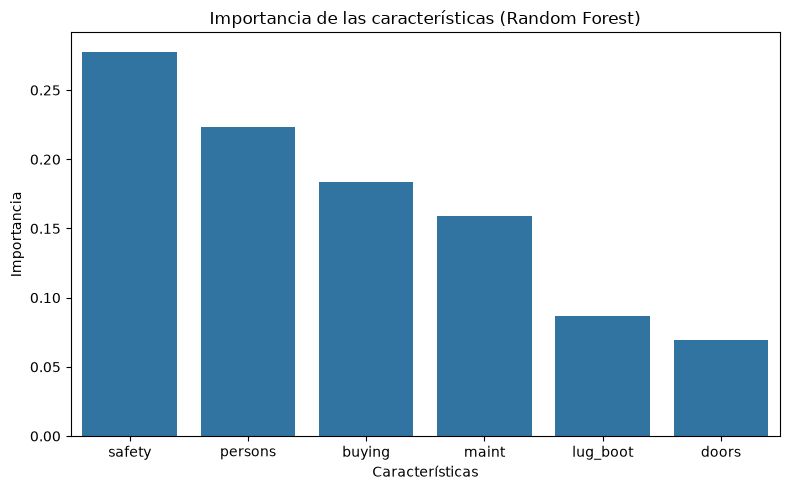

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.index, y=importancias.values)
plt.title('Importancia de las características (Random Forest)')
plt.xlabel('Características')
plt.ylabel('Importancia')
plt.tight_layout()
plt.show()

## 9. Reconstruir el modelo con las características seleccionadas

Elimina la variable **menos importante**, reconstruye el modelo y compara la exactitud.

In [16]:
# Nuevo conjunto de variables sin 'doors'

variable_eliminar = importancias.index[-1]
print(f"Variable menos importante: {variable_eliminar}")


X_reducido = df.drop(['class', variable_eliminar], axis=1)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reducido, y, test_size=0.2, random_state=42, stratify=y)

#Se elimina la variable de las categorias del enconder
categorias_restantes = [
    cat for col, cat in zip(X.columns, encoder.categories_) if col != variable_eliminar
]
ordinal_enc_r = OrdinalEncoder(categories=categorias_restantes)
Xr_train_enc = ordinal_enc_r.fit_transform(Xr_train)
Xr_test_enc = ordinal_enc_r.transform(Xr_test)

#Reconstruccion del modelo sin la variable doors
rf_sel = RandomForestClassifier(n_estimators=100, random_state=42)
rf_sel.fit(Xr_train_enc, yr_train)
yr_pred = rf_sel.predict(Xr_test_enc)
acc_sel = accuracy_score(yr_test, yr_pred)

print(f"Exactitud con todas las variables : {acc_100:.4f}")
print(f"Exactitud sin '{variable_eliminar}'    : {acc_sel:.4f}")
print("Nota: La exactitud baja un poco porque aunque la variable que se quito era la menos importante," \
" sigue aportando información al modelo, esto tambien sigunifica que el modelo es robusto porque la difeerencia fue muy pequeña.")

Variable menos importante: doors
Exactitud con todas las variables : 0.9827
Exactitud sin 'doors'    : 0.9595
Nota: La exactitud baja un poco porque aunque la variable que se quito era la menos importante, sigue aportando información al modelo, esto tambien sigunifica que el modelo es robusto porque la difeerencia fue muy pequeña.


## 10. Crea un Reporte de clasificación

Muestra **precision**, **recall**, **f1-score** y **support** por clase.

In [17]:
from sklearn.metrics import classification_report

class_names = enc_y.categories_[0]
print(classification_report(y_test_enc, y_pred_100, target_names=class_names))

              precision    recall  f1-score   support

         acc       0.97      0.95      0.96        77
        good       0.93      0.93      0.93        14
       unacc       0.99      1.00      0.99       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.98       346
   macro avg       0.97      0.95      0.96       346
weighted avg       0.98      0.98      0.98       346

